**Libraries Imported**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

**Data Loading**

In [2]:
# Upload diabetic_data.csv via the Files panel on the left in Colab
df = pd.read_csv('diabetic_data.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


**Snapshot BEFORE cleaning**

In [3]:
print(f"\n Shape        : {df.shape}")
print(f" Duplicates   : {df.duplicated().sum()} full row duplicates")
print(f" Duplicated patients : {df['patient_nbr'].duplicated().sum()} repeated patient IDs")

print("\n '?' missing values:")
for col in df.columns:
    q = (df[col] == '?').sum()
    if q > 0:
        print(f"   {col:} → {q:}  ({q/len(df)*100:.1f}%)")

print("\nReal NaN missing values:")
nans = df.isnull().sum()
print(nans[nans > 0])

print("\nTarget distribution:")
print(df['readmitted'].value_counts())


 Shape        : (101766, 50)
 Duplicates   : 0 full row duplicates
 Duplicated patients : 30248 repeated patient IDs

 '?' missing values:
   race → 2273  (2.2%)
   weight → 98569  (96.9%)
   payer_code → 40256  (39.6%)
   medical_specialty → 49949  (49.1%)
   diag_1 → 21  (0.0%)
   diag_2 → 358  (0.4%)
   diag_3 → 1423  (1.4%)

Real NaN missing values:
max_glu_serum    96420
A1Cresult        84748
dtype: int64

Target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


**Replace "?" with NaN**

In [4]:
# This is the most important first step — '?' is NOT a real value
df.replace('?', np.nan, inplace=True)

print("\nMissing values now:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print("\n")
#checking if there "?"
print (df.isnull().values)


Missing values now:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


**Fix duplicate patient encounters**

In [5]:
print("Rows before:", len(df))

# Sort chronologically
df = df.sort_values('encounter_id')

# --- Visit count summary ---
visit_counts = df.groupby('patient_nbr')['encounter_id'] \
                 .count() \
                 .reset_index() \
                 .rename(columns={'encounter_id': 'num_visits'})

total_patients    = len(visit_counts)
single_visit      = (visit_counts['num_visits'] == 1).sum()
repeated_patients = (visit_counts['num_visits'] > 1).sum()
max_visits        = visit_counts['num_visits'].max()
avg_visits        = visit_counts['num_visits'].mean()

print("        PATIENT VISIT SUMMARY")
print(f"\n  Total unique patients     : {total_patients:,}")
print(f"  Visited only once         : {single_visit:,}")
print(f"  Visited more than once    : {repeated_patients:,}")
print(f"  Average visits/patient    : {avg_visits:.1f}")
print(f"  Most visits by 1 patient  : {max_visits}")

print("\n  How many patients per visit count:")
print(f"  {'Visits':<10} {'Patients'}")
print(f"  {'-'*25}")
for visits, count in visit_counts['num_visits'].value_counts() \
                     .sort_index().items():
    print(f"  {visits:<10} {count:,}")

# --- Engineer history features ---
df['total_encounters']       = df.groupby('patient_nbr')['encounter_id'].transform('count')
df['ever_readmitted']        = df.groupby('patient_nbr')['readmitted'].transform(lambda x: x.eq('<30').any().astype(int))
df['max_inpatient_history']  = df.groupby('patient_nbr')['number_inpatient'].transform('max')
df['mean_medications_history']= df.groupby('patient_nbr')['num_medications'].transform('mean').round(1)

# --- Deduplicate ---
df = df.drop_duplicates(subset='patient_nbr', keep='first')

print(f"\n Rows after deduplication: {len(df):,}")

Rows before: 101766
        PATIENT VISIT SUMMARY

  Total unique patients     : 71,518
  Visited only once         : 54,745
  Visited more than once    : 16,773
  Average visits/patient    : 1.4
  Most visits by 1 patient  : 40

  How many patients per visit count:
  Visits     Patients
  -------------------------
  1          54,745
  2          10,434
  3          3,328
  4          1,421
  5          717
  6          346
  7          207
  8          111
  9          70
  10         42
  11         20
  12         19
  13         14
  14         5
  15         9
  16         4
  17         3
  18         6
  19         3
  20         6
  21         1
  22         2
  23         3
  28         1
  40         1

 Rows after deduplication: 71,518


**Drop columns with too many missing values**

In [6]:
cols_to_drop = [
    'encounter_id',       # just an ID, not a feature
    'patient_nbr',        # just an ID
    'weight',             # 97% missing — unusable
    'payer_code',         # 40% missing + not clinically useful
    'medical_specialty',  # 49% missing
    'examide',            # only one unique value — zero variance
    'citoglipton',        # only one unique value — zero variance
]

df.drop(columns=cols_to_drop, inplace=True)

print("Done low-value columns Dropped")
print("Remaining shape:", df.shape)
print("Remaining columns:", df.columns.tolist())

Done low-value columns Dropped
Remaining shape: (71518, 47)
Remaining columns: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'total_encounters', 'ever_readmitted', 'max_inpatient_history', 'mean_medications_history']


**Handle remaining missing values**

In [7]:
# A1Cresult and max_glu_serum: NaN means "test was not done" → fill with 'None'
df['A1Cresult'].fillna('None', inplace=True)
df['max_glu_serum'].fillna('None', inplace=True)

# race: NaN means unknown → fill with 'Unknown'
df['race'].fillna('Unknown', inplace=True)

# diag_1, diag_2, diag_3: fill missing with '0' (unknown diagnosis)
df['diag_1'].fillna('0', inplace=True)
df['diag_2'].fillna('0', inplace=True)
df['diag_3'].fillna('0', inplace=True)

print("Done Handling Missing values")
print("\nRemaining NaNs:", df.isnull().sum().sum())

Done Handling Missing values

Remaining NaNs: 0


**Fix the age column (bins → numbers)**

In [8]:
# Age is convert to midpoint integers
age_mapping = {
    '[0-10)'  : 5,
    '[10-20)' : 15,
    '[20-30)' : 25,
    '[30-40)' : 35,
    '[40-50)' : 45,
    '[50-60)' : 55,
    '[60-70)' : 65,
    '[70-80)' : 75,
    '[80-90)' : 85,
    '[90-100)': 95
}

df['age'] = df['age'].map(age_mapping)

print("Done Age Convert to numeric midpoints")
print(df['age'].value_counts().sort_index())

Done Age Convert to numeric midpoints
age
5       154
15      535
25     1127
35     2699
45     6878
55    12466
65    15960
75    18210
85    11589
95     1900
Name: count, dtype: int64


**Group ICD-9 diagnosis codes into disease categories**

In [9]:
def map_icd9(code):
    """Map ICD-9 code to broad disease category"""
    try:
        code = str(code).strip()
        if code.startswith('V') or code.startswith('E'):
            return 'Other'
        c = float(code)
        if 390 <= c <= 459 or c == 785:
            return 'Circulatory'
        elif 460 <= c <= 519 or c == 786:
            return 'Respiratory'
        elif 520 <= c <= 579 or c == 787:
            return 'Digestive'
        elif 250 <= c <= 250.99:
            return 'Diabetes'
        elif 800 <= c <= 999:
            return 'Injury'
        elif 710 <= c <= 739:
            return 'Musculoskeletal'
        elif 580 <= c <= 629 or c == 788:
            return 'Genitourinary'
        elif 140 <= c <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Other'

df['diag_1'] = df['diag_1'].apply(map_icd9)
df['diag_2'] = df['diag_2'].apply(map_icd9)
df['diag_3'] = df['diag_3'].apply(map_icd9)

print("Done Diagnosis codes grouped into disease categories")

for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    print(f"\n{diag_col} distribution:")
    print("----------------------------")
    counts = df[diag_col].value_counts()
    total = counts.sum()
    for category, count in counts.items():
        print(f"  {category:<20} : {count:>6,}  ({count/total*100:.1f}%)")
    print(f"  {'TOTAL':<20} : {total:>6,}")

Done Diagnosis codes grouped into disease categories

diag_1 distribution:
----------------------------
  Circulatory          : 21,894  (30.6%)
  Other                : 12,358  (17.3%)
  Respiratory          :  9,776  (13.7%)
  Digestive            :  6,570  (9.2%)
  Diabetes             :  5,805  (8.1%)
  Injury               :  4,779  (6.7%)
  Musculoskeletal      :  4,080  (5.7%)
  Genitourinary        :  3,514  (4.9%)
  Neoplasms            :  2,742  (3.8%)
  TOTAL                : 71,518

diag_2 distribution:
----------------------------
  Circulatory          : 22,534  (31.5%)
  Other                : 18,703  (26.2%)
  Diabetes             :  9,759  (13.6%)
  Respiratory          :  7,242  (10.1%)
  Genitourinary        :  5,468  (7.6%)
  Digestive            :  2,907  (4.1%)
  Injury               :  1,858  (2.6%)
  Neoplasms            :  1,750  (2.4%)
  Musculoskeletal      :  1,297  (1.8%)
  TOTAL                : 71,518

diag_3 distribution:
----------------------------
  O

**Create the binary target variable**

In [10]:
# Original: 3 classes — NO, >30, <30 -->> make them 2classes (Yes, No)

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
print("was the patient readmitted within 30 days? (yes:1 , No:0)")
print("Done creation Binary target")
print("\nClass distribution:")
print(df['readmitted_binary'].value_counts())
print(f"\nReadmission rate: {df['readmitted_binary'].mean()*100:.1f}%")

# Drop original target
df.drop(columns=['readmitted'], inplace=True)

was the patient readmitted within 30 days? (yes:1 , No:0)
Done creation Binary target

Class distribution:
readmitted_binary
0    65225
1     6293
Name: count, dtype: int64

Readmission rate: 8.8%


**Drop near-zero variance medication columns**

In [11]:
# Most medication columns are 95%+ "No" — they add noise, not signal
med_cols = ['acarbose','chlorpropamide','acetohexamide','tolbutamide','miglitol','troglitazone','tolazamide','glimepiride-pioglitazone',
            'metformin-rosiglitazone','metformin-pioglitazone','glipizide-metformin','glyburide-metformin','insulin',
            'pioglitazone','rosiglitazone','glyburide','glipizide','glimepiride','nateglinide','repaglinide','metformin']

# Only drop if >95% are "No"
to_drop = []
for col in med_cols:
    if col in df.columns:
        no_pct = (df[col] == 'No').mean()
        if no_pct > 0.95:
            to_drop.append(col)
            print(f"  Dropping {col} ({no_pct*100:.1f}% 'No')")

df.drop(columns=to_drop, inplace=True)
print(f"\nDone Dropping {len(to_drop)} near-zero variance medication columns")
print("Shape:", df.shape)

  Dropping acarbose (99.7% 'No')
  Dropping chlorpropamide (99.9% 'No')
  Dropping acetohexamide (100.0% 'No')
  Dropping tolbutamide (100.0% 'No')
  Dropping miglitol (100.0% 'No')
  Dropping troglitazone (100.0% 'No')
  Dropping tolazamide (100.0% 'No')
  Dropping glimepiride-pioglitazone (100.0% 'No')
  Dropping metformin-rosiglitazone (100.0% 'No')
  Dropping metformin-pioglitazone (100.0% 'No')
  Dropping glipizide-metformin (100.0% 'No')
  Dropping glyburide-metformin (99.3% 'No')
  Dropping nateglinide (99.3% 'No')
  Dropping repaglinide (98.7% 'No')

Done Dropping 14 near-zero variance medication columns
Shape: (71518, 33)


**Encode remaining categorical columns**

In [12]:
from sklearn.preprocessing import LabelEncoder

# These categorical columns need to be numbers for ML models
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\n Done Encoding of All categorical columns")
print(df.dtypes)

Categorical columns to encode: ['race', 'gender', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed']

 Done Encoding of All categorical columns
race                          int64
gender                        int64
age                           int64
admission_type_id             int64
discharge_disposition_id      int64
admission_source_id           int64
time_in_hospital              int64
num_lab_procedures            int64
num_procedures                int64
num_medications               int64
number_outpatient             int64
number_emergency              int64
number_inpatient              int64
diag_1                        int64
diag_2                        int64
diag_3                        int64
number_diagnoses              int64
max_glu_serum                 int64
A1Cresult                     int64
metformin                     int64
glim

**Final snapshot & save**

In [13]:
print("AFTER CLEANING — FINAL REPORT")
print(f"\n Rows     : {len(df)}")
print(f"Columns  : {df.shape[1]}")
print(f"Nulls    : {df.isnull().sum().sum()}")
print(f"Target balance:")
print(df['readmitted_binary'].value_counts())
print(f"\nFinal columns:")
print(df.columns.tolist())

# Save
df.to_csv('diabetic_cleaned.csv', index=False)
print("\nSaved as diabetic_cleaned.csv")

df.head()

AFTER CLEANING — FINAL REPORT

 Rows     : 71518
Columns  : 33
Nulls    : 0
Target balance:
readmitted_binary
0    65225
1     6293
Name: count, dtype: int64

Final columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'total_encounters', 'ever_readmitted', 'max_inpatient_history', 'mean_medications_history', 'readmitted_binary']

Saved as diabetic_cleaned.csv


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,pioglitazone,rosiglitazone,insulin,change,diabetesMed,total_encounters,ever_readmitted,max_inpatient_history,mean_medications_history,readmitted_binary
8,2,0,85,2,1,4,13,68,2,28,...,1,1,2,0,1,1,0,0,28.0,0
9,2,0,95,3,3,4,12,33,3,18,...,1,2,2,0,1,1,0,0,18.0,0
4,2,1,45,1,1,7,1,51,0,8,...,1,1,2,0,1,1,0,0,8.0,0
10,0,0,45,1,1,7,9,47,2,17,...,1,1,2,1,1,1,0,0,17.0,0
5,2,1,55,2,1,2,3,31,6,16,...,1,1,2,1,1,1,0,0,16.0,0


**Creating File for filtered data**

In [14]:
df.to_csv('diabetic_cleaned.csv', index=False)
print(f"Saved as diabetic_cleaned.csv")
print(f"   Shape : {df.shape}")
print(f"   Nulls : {df.isnull().sum().sum()}")

from google.colab import files
files.download('diabetic_cleaned.csv')

Saved as diabetic_cleaned.csv
   Shape : (71518, 33)
   Nulls : 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**EDA Steps**

**Setup**

In [15]:
# Clean visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

df = pd.read_csv('diabetic_cleaned.csv')
print("Shape:", df.shape)
print("Target balance:")
print(df['readmitted_binary'].value_counts())

Shape: (71518, 33)
Target balance:
readmitted_binary
0    65225
1     6293
Name: count, dtype: int64


**Plot1: Univariate: Target distribution (Bar plot)**

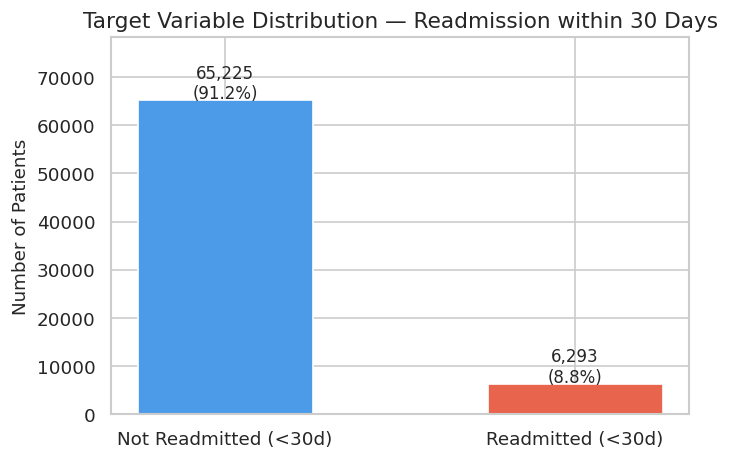

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['readmitted_binary'].value_counts()
labels = ['Not Readmitted (<30d)', 'Readmitted (<30d)']
colors = ['#4C9BE8', '#E8644C']

bars = ax.bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')

# Add count labels on bars
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=10)

ax.set_title('Target Variable Distribution — Readmission within 30 Days')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.savefig('plot1_target_distribution.png')
plt.show()

**Plot2: Univariate: Age distribution (Histogram)**

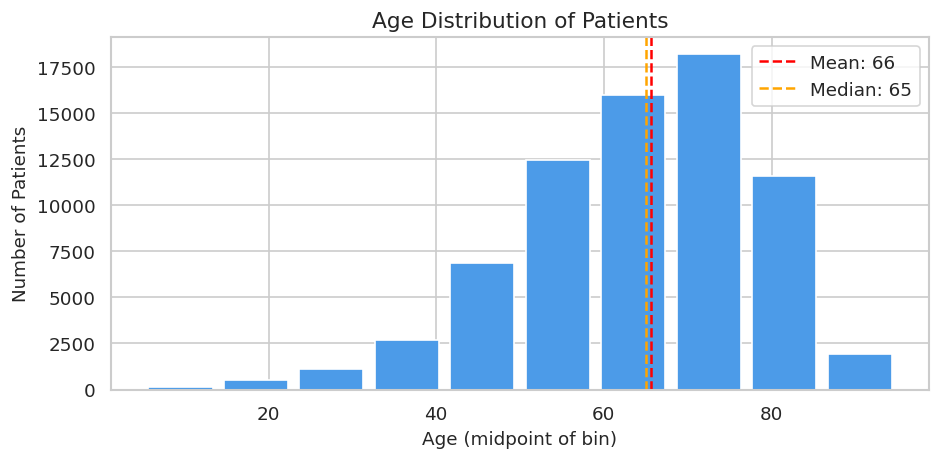

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['age'], bins=10, color='#4C9BE8', edgecolor='white', rwidth=0.85)
ax.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.0f}")
ax.axvline(df['age'].median(), color='orange', linestyle='--', label=f"Median: {df['age'].median():.0f}")

ax.set_title('Age Distribution of Patients')
ax.set_xlabel('Age (midpoint of bin)')
ax.set_ylabel('Number of Patients')
ax.legend()
plt.tight_layout()
plt.savefig('plot2_age_distribution.png')
plt.show()

**Plot3: Univariate: Time in hospital (Boxplot)**

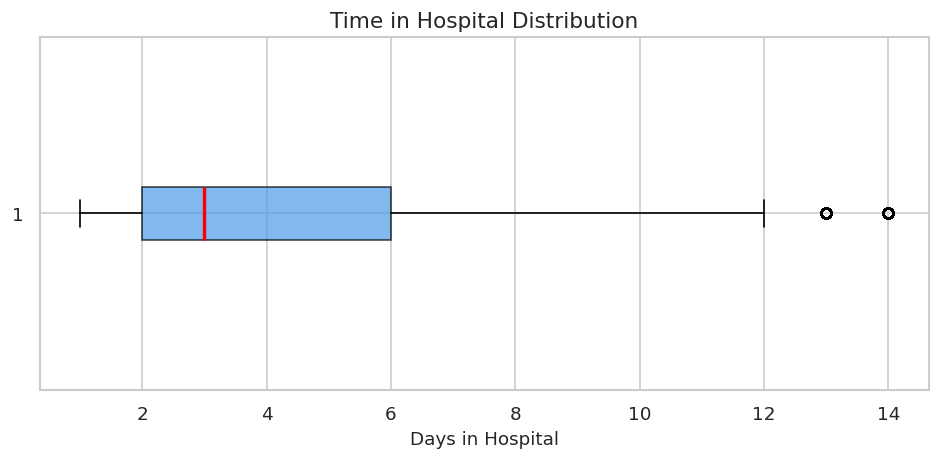

Min   : 1 days
Median: 3.0 days
Max   : 14 days


In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.boxplot(df['time_in_hospital'], vert=False,
           patch_artist=True,
           boxprops=dict(facecolor='#4C9BE8', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))

ax.set_title('Time in Hospital Distribution')
ax.set_xlabel('Days in Hospital')
plt.tight_layout()
plt.savefig('plot3_time_in_hospital.png')
plt.show()

print(f"Min   : {df['time_in_hospital'].min()} days")
print(f"Median: {df['time_in_hospital'].median()} days")
print(f"Max   : {df['time_in_hospital'].max()} days")

**Plot4: Univariate: Top medical conditions via diag_1 (Horizontal bar)**

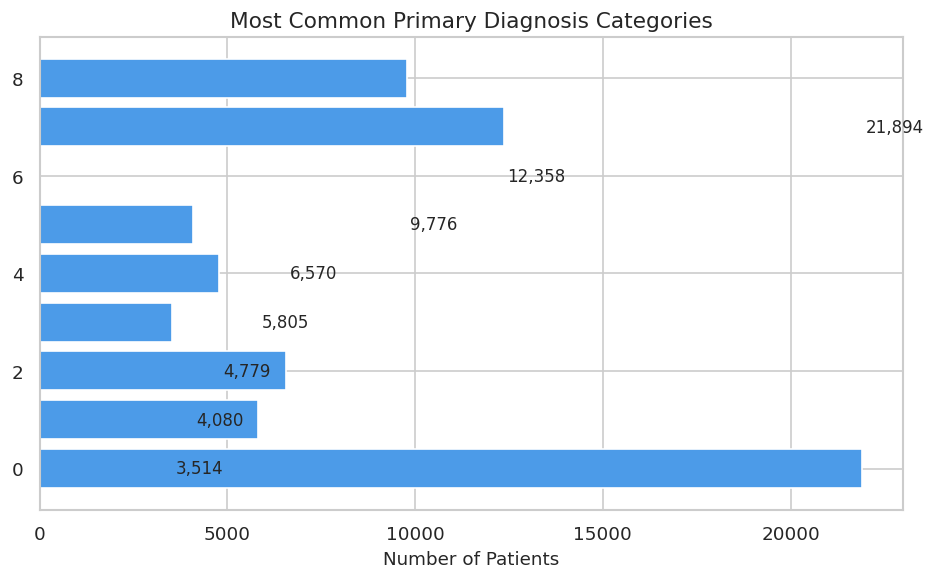

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

top_diag = df['diag_1'].value_counts().head(8)

ax.barh(top_diag.index[::-1], top_diag.values[::-1],
        color='#4C9BE8', edgecolor='white')

for i, val in enumerate(top_diag.values[::-1]):
    ax.text(val + 100, i, f'{val:,}', va='center', fontsize=10)

ax.set_title('Most Common Primary Diagnosis Categories')
ax.set_xlabel('Number of Patients')
plt.tight_layout()
plt.savefig('plot4_top_diagnoses.png')
plt.show()

**Plot5: Bivariate: Age vs Readmission (Boxplot)**

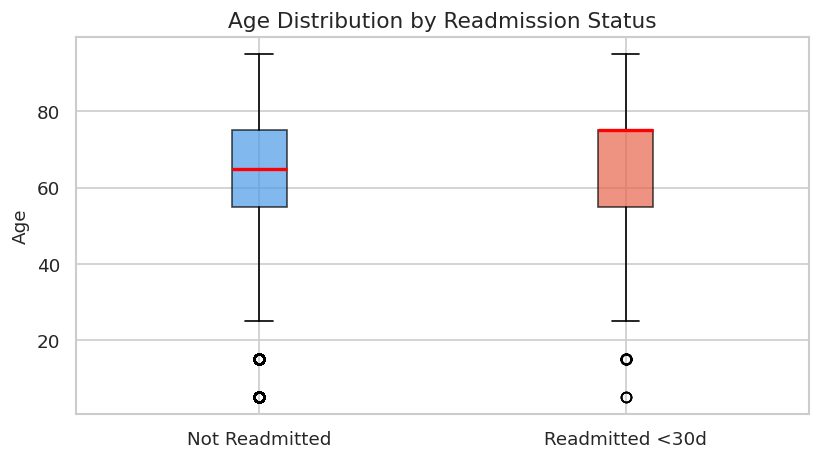

Mean age — Not readmitted: 65.4
Mean age — Readmitted    : 67.8


In [20]:
fig, ax = plt.subplots(figsize=(7, 4))

groups = [df[df['readmitted_binary'] == 0]['age'],
          df[df['readmitted_binary'] == 1]['age']]

bp = ax.boxplot(groups, vert=True, patch_artist=True,
                labels=['Not Readmitted', 'Readmitted <30d'],
                boxprops=dict(alpha=0.7),
                medianprops=dict(color='red', linewidth=2))

bp['boxes'][0].set_facecolor('#4C9BE8')
bp['boxes'][1].set_facecolor('#E8644C')

ax.set_title('Age Distribution by Readmission Status')
ax.set_ylabel('Age')
plt.tight_layout()
plt.savefig('plot5_age_vs_readmission.png')
plt.show()

# Quick stat
print("Mean age — Not readmitted:", df[df['readmitted_binary']==0]['age'].mean().round(1))
print("Mean age — Readmitted    :", df[df['readmitted_binary']==1]['age'].mean().round(1))

**Plot6: Bivariate: Number of medications vs Readmission (Violin plot)**

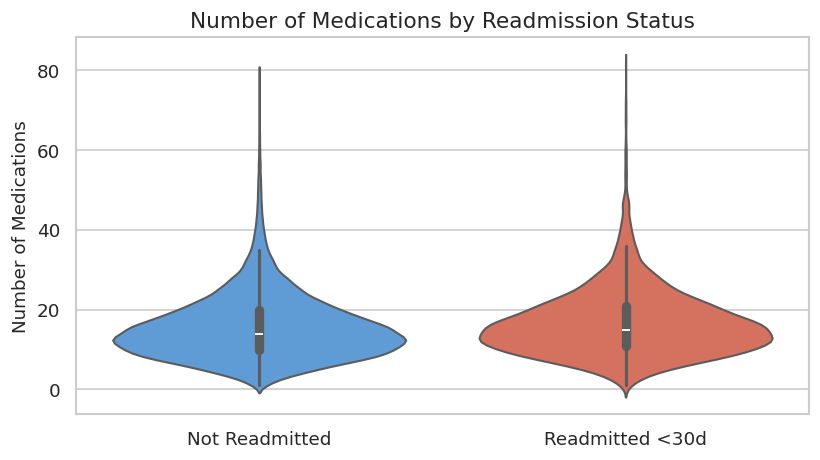

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.violinplot(data=df, x='readmitted_binary', y='num_medications',
               palette=['#4C9BE8', '#E8644C'], ax=ax)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Readmitted', 'Readmitted <30d'])
ax.set_title('Number of Medications by Readmission Status')
ax.set_ylabel('Number of Medications')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('plot6_medications_vs_readmission.png')
plt.show()

**Plot7: Bivariate: Readmission rate by race (Bar plot)**

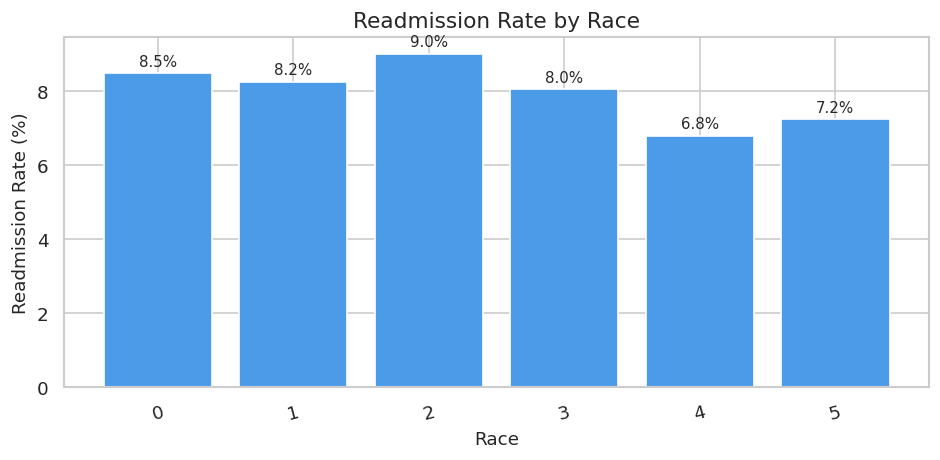

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

race_readmit = df.groupby('race')['readmitted_binary'].mean().sort_values(ascending=False)

bars = ax.bar(race_readmit.index, race_readmit.values * 100,
              color='#4C9BE8', edgecolor='white')

for bar, val in zip(bars, race_readmit.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{val*100:.1f}%', ha='center', fontsize=9)

ax.set_title('Readmission Rate by Race')
ax.set_ylabel('Readmission Rate (%)')
ax.set_xlabel('Race')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plot7_readmission_by_race.png')
plt.show()

**Plot8: Bivariate: Correlation heatmap (Heatmap)**

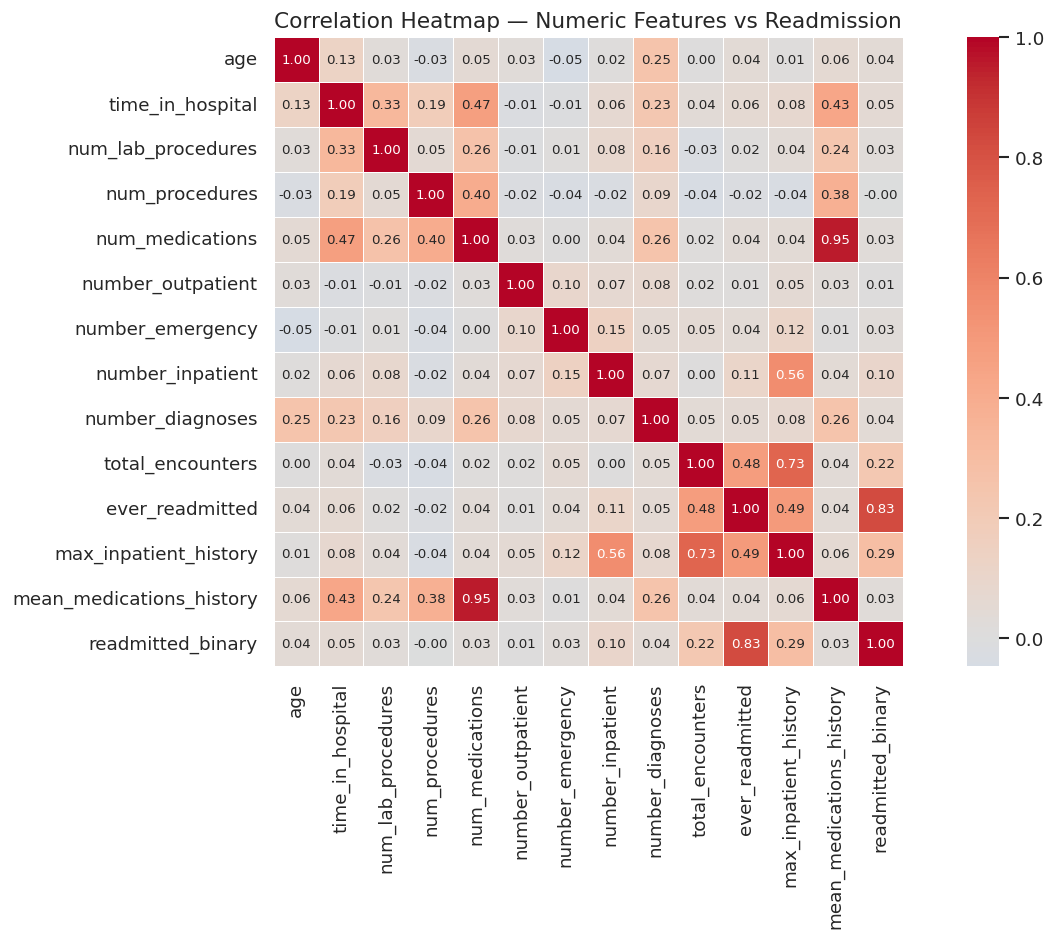


Top correlations with readmitted_binary:
ever_readmitted          0.827411
max_inpatient_history    0.293019
total_encounters         0.223478
number_inpatient         0.099237
time_in_hospital         0.053531
age                      0.042717
number_diagnoses         0.041741
num_medications          0.034204
Name: readmitted_binary, dtype: float64


In [23]:
fig, ax = plt.subplots(figsize=(12, 8))

# Select only numeric columns for correlation
numeric_cols = ['age', 'time_in_hospital', 'num_lab_procedures',
                'num_procedures', 'num_medications', 'number_outpatient',
                'number_emergency', 'number_inpatient', 'number_diagnoses',
                'total_encounters', 'ever_readmitted',
                'max_inpatient_history', 'mean_medications_history',
                'readmitted_binary']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)

ax.set_title('Correlation Heatmap — Numeric Features vs Readmission')
plt.tight_layout()
plt.savefig('plot8_correlation_heatmap.png')
plt.show()

# Print top correlations with target
print("\nTop correlations with readmitted_binary:")
print(corr['readmitted_binary'].drop('readmitted_binary') \
      .abs().sort_values(ascending=False).head(8))

**Plot9: Bivariate: Inpatient visits vs Readmission (Countplot)**

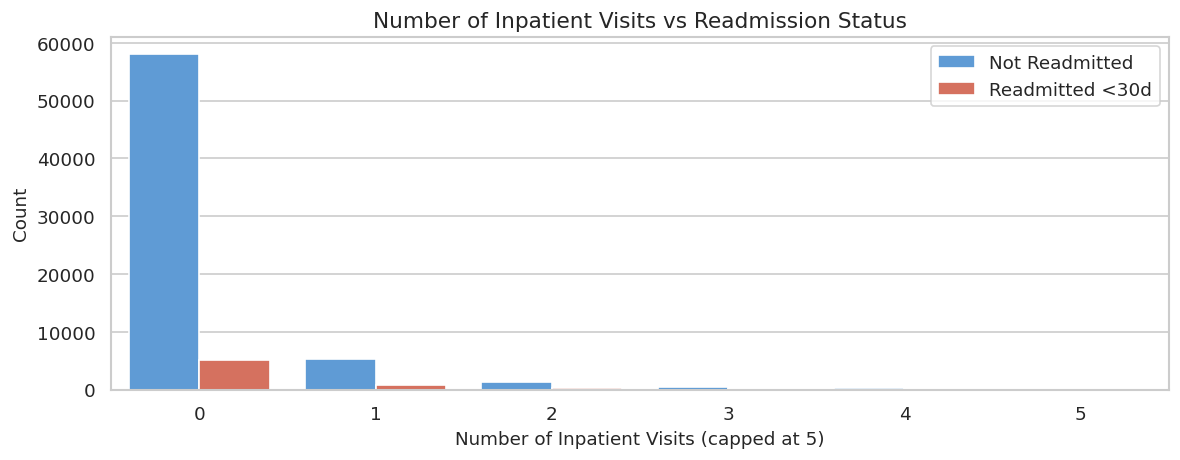

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))

# Cap at 5 for readability
df['inpatient_capped'] = df['number_inpatient'].clip(0, 5)

sns.countplot(data=df, x='inpatient_capped',
              hue='readmitted_binary',
              palette=['#4C9BE8', '#E8644C'], ax=ax)

ax.set_title('Number of Inpatient Visits vs Readmission Status')
ax.set_xlabel('Number of Inpatient Visits (capped at 5)')
ax.set_ylabel('Count')
ax.legend(labels=['Not Readmitted', 'Readmitted <30d'], title='')
plt.tight_layout()
plt.savefig('plot9_inpatient_vs_readmission.png')
plt.show()

 **Feature Engineering & Feature Selection**

**1 — Check current state of the data**


In [25]:
df = pd.read_csv('diabetic_cleaned.csv')

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes.value_counts())
print("\nColumns:")
print(df.columns.tolist())

Shape: (71518, 33)

Column types:
int64      32
float64     1
Name: count, dtype: int64

Columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'total_encounters', 'ever_readmitted', 'max_inpatient_history', 'mean_medications_history', 'readmitted_binary']


**2 — Identify which columns need One-Hot Encoding**

In [26]:
# Nominal categories — no natural order — must be One-Hot Encoded
nominal_cols = ['race', 'gender', 'diag_1', 'diag_2', 'diag_3',
                'max_glu_serum', 'A1Cresult']

# These have natural order — Label Encoding is fine
ordinal_cols = ['metformin', 'glimepiride', 'glipizide', 'glyburide',
                'pioglitazone', 'rosiglitazone', 'acarbose',
                'insulin', 'change', 'diabetesMed']

print("Nominal columns (One-Hot):")
for col in nominal_cols:
    if col in df.columns:
        print(f"  {col:<25} → {df[col].nunique()} unique values: {df[col].unique().tolist()}")

print("\nOrdinal columns (Label Encode):")
for col in ordinal_cols:
    if col in df.columns:
        print(f"  {col:<25} → {df[col].unique().tolist()}")

Nominal columns (One-Hot):
  race                      → 6 unique values: [2, 0, 5, 4, 1, 3]
  gender                    → 3 unique values: [0, 1, 2]
  diag_1                    → 9 unique values: [0, 6, 1, 8, 7, 4, 5, 2, 3]
  diag_2                    → 9 unique values: [0, 6, 7, 1, 4, 8, 5, 3, 2]
  diag_3                    → 9 unique values: [7, 8, 1, 4, 6, 0, 3, 5, 2]
  max_glu_serum             → 4 unique values: [2, 1, 3, 0]
  A1Cresult                 → 4 unique values: [2, 0, 1, 3]

Ordinal columns (Label Encode):
  metformin                 → [1, 2, 3, 0]
  glimepiride               → [1, 2, 0, 3]
  glipizide                 → [2, 1, 3, 0]
  glyburide                 → [1, 3, 2, 0]
  pioglitazone              → [1, 2, 3, 0]
  rosiglitazone             → [1, 2, 3, 0]
  insulin                   → [2, 0, 1, 3]
  change                    → [0, 1]
  diabetesMed               → [1, 0]


**3 — Fix encoding: One-Hot Encode nominal columns**

In [27]:
# Drop Label Encoding applied earlier on nominal columns
# Replace with proper One-Hot Encoding

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("One-Hot Encoding applied")
print("Shape before:", df.shape)
print("Shape after :", df_encoded.shape)
print("\nNew columns added:")
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(new_cols)

One-Hot Encoding applied
Shape before: (71518, 33)
Shape after : (71518, 63)

New columns added:
['race_1', 'race_2', 'race_3', 'race_4', 'race_5', 'gender_1', 'gender_2', 'diag_1_1', 'diag_1_2', 'diag_1_3', 'diag_1_4', 'diag_1_5', 'diag_1_6', 'diag_1_7', 'diag_1_8', 'diag_2_1', 'diag_2_2', 'diag_2_3', 'diag_2_4', 'diag_2_5', 'diag_2_6', 'diag_2_7', 'diag_2_8', 'diag_3_1', 'diag_3_2', 'diag_3_3', 'diag_3_4', 'diag_3_5', 'diag_3_6', 'diag_3_7', 'diag_3_8', 'max_glu_serum_1', 'max_glu_serum_2', 'max_glu_serum_3', 'A1Cresult_1', 'A1Cresult_2', 'A1Cresult_3']


**4 — Label Encode ordinal medication columns**

In [28]:
order_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

for col in ordinal_cols:
    if col in df_encoded.columns:
        if df_encoded[col].dtype == object:
            df_encoded[col] = df_encoded[col].map(order_map)
            print(f"{col} encoded")

# change and diabetesMed are binary
if 'change' in df_encoded.columns:
    df_encoded['change'] = (df_encoded['change'] == 'Ch').astype(int)

if 'diabetesMed' in df_encoded.columns:
    df_encoded['diabetesMed'] = (df_encoded['diabetesMed'] == 'Yes').astype(int)

print("\n Ordinal encoding done")
print("Remaining object columns:", df_encoded.select_dtypes('object').columns.tolist())


 Ordinal encoding done
Remaining object columns: []


**5 — Engineer new features**

In [29]:
# Feature 1: Total services used (how complex was the visit?)
df_encoded['total_services'] = (df_encoded['num_lab_procedures'] +
                                 df_encoded['num_procedures'] +
                                 df_encoded['num_medications'])

# Feature 2: Has prior emergency visits? (binary flag)
df_encoded['has_emergency_history'] = (df_encoded['number_emergency'] > 0).astype(int)

# Feature 3: Medication change intensity
# Counts how many medications were changed (Up or Down) — proxy for unstable condition
med_change_cols = ['metformin', 'glimepiride', 'glipizide',
                   'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']
existing = [c for c in med_change_cols if c in df_encoded.columns]
df_encoded['num_meds_changed'] = df_encoded[existing].apply(
    lambda row: (row > 1).sum(), axis=1
)

# Feature 4: High utilizer flag (frequent inpatient + emergency visits)
df_encoded['high_utilizer'] = (
    (df_encoded['number_inpatient'] >= 2) |
    (df_encoded['number_emergency'] >= 2)
).astype(int)

print(" New features engineered:")
print("  1. total_services         — complexity of the visit")
print("  2. has_emergency_history  — any prior emergency visits")
print("  3. num_meds_changed       — medication instability proxy")
print("  4. high_utilizer          — frequent hospital user flag")
print("\nShape:", df_encoded.shape)

 New features engineered:
  1. total_services         — complexity of the visit
  2. has_emergency_history  — any prior emergency visits
  3. num_meds_changed       — medication instability proxy
  4. high_utilizer          — frequent hospital user flag

Shape: (71518, 67)


**6 — Feature Selection using Filter Method (Correlation)**

In [30]:
# Filter Method: remove features with very low correlation to target

X = df_encoded.drop(columns=['readmitted_binary'])
y = df_encoded['readmitted_binary']

# Calculate correlation of every feature with target
correlations = X.corrwith(y).abs().sort_values(ascending=False)

print("Top 15 features correlated with readmission:")
print("=" * 45)
for feat, corr in correlations.head(15).items():
    bar = '█' * int(corr * 100)
    print(f"  {feat:<35} {corr:.4f}  {bar}")

print("\nBottom 10 features (weakest signal):")
print(correlations.tail(10).to_string())

# Drop features with near-zero correlation (< 0.01)
weak_features = correlations[correlations < 0.01].index.tolist()
print(f"\n  Dropping {len(weak_features)} near-zero correlation features:")
print(weak_features)

X_filtered = X.drop(columns=weak_features)
print(f"\n Features after filter selection: {X_filtered.shape[1]}")

Top 15 features correlated with readmission:
  ever_readmitted                     0.8274  ██████████████████████████████████████████████████████████████████████████████████
  max_inpatient_history               0.2930  █████████████████████████████
  total_encounters                    0.2235  ██████████████████████
  number_inpatient                    0.0992  █████████
  high_utilizer                       0.0775  ███████
  discharge_disposition_id            0.0576  █████
  time_in_hospital                    0.0535  █████
  age                                 0.0427  ████
  number_diagnoses                    0.0417  ████
  total_services                      0.0359  ███
  num_medications                     0.0342  ███
  mean_medications_history            0.0315  ███
  has_emergency_history               0.0299  ██
  num_lab_procedures                  0.0289  ██
  number_emergency                    0.0282  ██

Bottom 10 features (weakest signal):
race_1               0.001623


**7 — Feature Selection using Embedded Method (Random Forest importance)**



In [31]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_filtered, y)

# Get feature importances
importances = pd.Series(rf.feature_importances_,
                        index=X_filtered.columns) \
                .sort_values(ascending=False)

print("Top 20 most important features (Random Forest):")
print("=" * 50)
for feat, imp in importances.head(20).items():
    bar = '█' * int(imp * 500)
    print(f"  {feat:<35} {imp:.4f}  {bar}")

# Keep top 20 features for modeling
top_features = importances.head(20).index.tolist()
X_final = X_filtered[top_features]

print(f"\n Final feature set: {X_final.shape[1]} features")
print(top_features)

Top 20 most important features (Random Forest):
  ever_readmitted                     0.6148  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  total_encounters                    0.0858  ██████████████████████████████████████████
  max_inpatient_history               0.0665  █████████████████████████████████
  mean_medications_history            0.0332  ████████████████
  total_services                      0.0309  ███████████████
  num_lab_procedures                  0.0293  ██████████████
  num_medications                     0.0269  █████████████
  time_in_hospital                    0.0200  ██████████
  age                                 0.0163  ████████
  discharge_disposition_id            0.0147  ███████
  number_inpatien

**8 — Save final feature set**

In [32]:
# Combine features + target and save
df_final = X_final.copy()
df_final['readmitted_binary'] = y.values

df_final.to_csv('diabetic_features.csv', index=False)

print(" Final dataset saved as diabetic_features.csv")
print(f"   Shape  : {df_final.shape}")
print(f"   Nulls  : {df_final.isnull().sum().sum()}")
print(f"\n   Features going into modeling:")
for i, col in enumerate(X_final.columns, 1):
    print(f"   {i:>2}. {col}")

 Final dataset saved as diabetic_features.csv
   Shape  : (71518, 21)
   Nulls  : 0

   Features going into modeling:
    1. ever_readmitted
    2. total_encounters
    3. max_inpatient_history
    4. mean_medications_history
    5. total_services
    6. num_lab_procedures
    7. num_medications
    8. time_in_hospital
    9. age
   10. discharge_disposition_id
   11. number_inpatient
   12. number_diagnoses
   13. diag_3_7
   14. metformin
   15. race_2
   16. number_emergency
   17. diag_1_8
   18. high_utilizer
   19. diag_1_4
   20. has_emergency_history


**Model Training**

**1 — Load final features & split data**

In [33]:
df_final = pd.read_csv('diabetic_features.csv')

X = df_final.drop(columns=['readmitted_binary'])
y = df_final['readmitted_binary']

print("Shape:", df_final.shape)
print(f"\nClass distribution:")
print(f"  0 (Not readmitted) : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"  1 (Readmitted <30d): {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")

# Split: 80% train, 20% test
# stratify=y ensures both splits have same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Train set : {X_train.shape[0]:,} rows")
print(f" Test set  : {X_test.shape[0]:,} rows")

Shape: (71518, 21)

Class distribution:
  0 (Not readmitted) : 65,225 (91.2%)
  1 (Readmitted <30d): 6,293 (8.8%)

 Train set : 57,214 rows
 Test set  : 14,304 rows


**2 — Handle class imbalance with SMOTE**

In [34]:
from imblearn.over_sampling import SMOTE

# Only 11% are readmitted — model will just predict 0 every time without this fix
# SMOTE creates synthetic minority samples to balance the classes

print("Before SMOTE:")
print(f"  Class 0: {(y_train==0).sum():,}")
print(f"  Class 1: {(y_train==1).sum():,}")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Class 0: {(y_train_bal==0).sum():,}")
print(f"  Class 1: {(y_train_bal==1).sum():,}")
print("\n Classes are now balanced for training")
print("  Note: SMOTE applied ONLY on train set — test set stays original")

Before SMOTE:
  Class 0: 52,180
  Class 1: 5,034

After SMOTE:
  Class 0: 52,180
  Class 1: 52,180

 Classes are now balanced for training
  Note: SMOTE applied ONLY on train set — test set stays original


**3 — Scale features**

In [35]:
from sklearn.preprocessing import StandardScaler

# Tree-based models don't need scaling
# but Logistic Regression does — so we scale for all to be fair

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print(" Features scaled using StandardScaler")
print("   fit() on train only — transform() on test")
print("   (prevents data leakage from test set into scaler)")

 Features scaled using StandardScaler
   fit() on train only — transform() on test
   (prevents data leakage from test set into scaler)


**4 — Train Model 1: Logistic Regression**

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import time

print("=" * 50)
print("MODEL 1 — Logistic Regression")
print("=" * 50)

start = time.time()
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_bal)
elapsed = time.time() - start

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(f"Training time : {elapsed:.2f}s")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Not Readmitted', 'Readmitted <30d']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob_lr):.4f}")

MODEL 1 — Logistic Regression
Training time : 1.03s

Classification Report:
                 precision    recall  f1-score   support

 Not Readmitted       1.00      0.97      0.98     13045
Readmitted <30d       0.74      0.98      0.84      1259

       accuracy                           0.97     14304
      macro avg       0.87      0.97      0.91     14304
   weighted avg       0.97      0.97      0.97     14304

ROC-AUC Score : 0.9902


**5 — Train Model 2: Random Forest**

In [37]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 50)
print("MODEL 2 — Random Forest")
print("=" * 50)

start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_bal)
elapsed = time.time() - start

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print(f"Training time : {elapsed:.2f}s")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Not Readmitted', 'Readmitted <30d']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob_rf):.4f}")

MODEL 2 — Random Forest
Training time : 9.88s

Classification Report:
                 precision    recall  f1-score   support

 Not Readmitted       0.99      0.97      0.98     13045
Readmitted <30d       0.77      0.94      0.85      1259

       accuracy                           0.97     14304
      macro avg       0.88      0.96      0.91     14304
   weighted avg       0.97      0.97      0.97     14304

ROC-AUC Score : 0.9938


**6 — Train Model 3: XGBoost**

In [38]:
from xgboost import XGBClassifier

print("=" * 50)
print("MODEL 3 — XGBoost")
print("=" * 50)

start = time.time()
xgb = XGBClassifier(random_state=42, eval_metric='logloss',
                    use_label_encoder=False, n_jobs=-1)
xgb.fit(X_train_scaled, y_train_bal)
elapsed = time.time() - start

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print(f"Training time : {elapsed:.2f}s")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Not Readmitted', 'Readmitted <30d']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob_xgb):.4f}")

MODEL 3 — XGBoost
Training time : 1.26s

Classification Report:
                 precision    recall  f1-score   support

 Not Readmitted       0.99      0.98      0.98     13045
Readmitted <30d       0.78      0.91      0.84      1259

       accuracy                           0.97     14304
      macro avg       0.89      0.94      0.91     14304
   weighted avg       0.97      0.97      0.97     14304

ROC-AUC Score : 0.9946


**7 — Compare all 3 models**

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Random Forest'      : (y_pred_rf, y_prob_rf),
    'XGBoost'            : (y_pred_xgb, y_prob_xgb),
}

print("=" * 70)
print(f"  {'Model':<25} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("=" * 70)

for name, (y_pred, y_prob) in results.items():
    p  = precision_score(y_test, y_pred)
    r  = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc= roc_auc_score(y_test, y_prob)
    print(f"  {name:<25} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {auc:>10.4f}")

print("=" * 70)
print("\n Best model is MODEL 3 — XGBoost")

  Model                      Precision     Recall         F1    ROC-AUC
  Logistic Regression           0.7393     0.9754     0.8411     0.9902
  Random Forest                 0.7683     0.9404     0.8457     0.9938
  XGBoost                       0.7794     0.9118     0.8404     0.9946

 Best model is MODEL 3 — XGBoost


**8 — Confusion matrices for all 3 models**

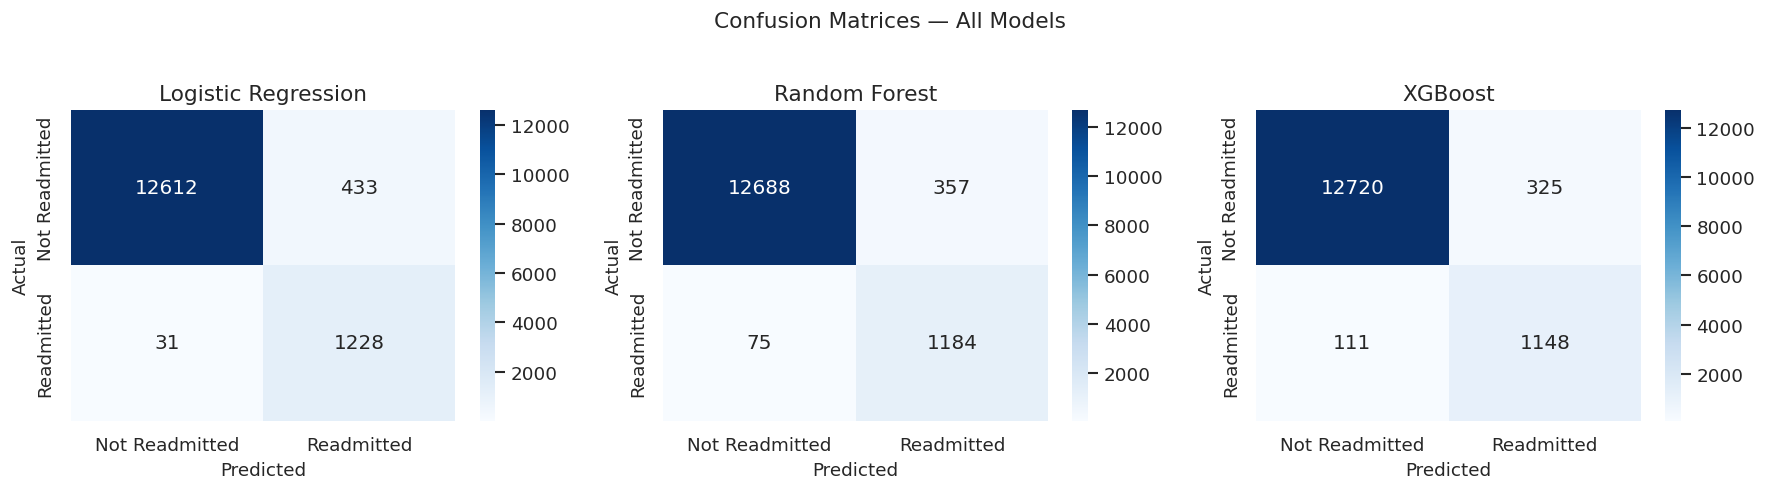

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png')
plt.show()

**9 — ROC Curves**

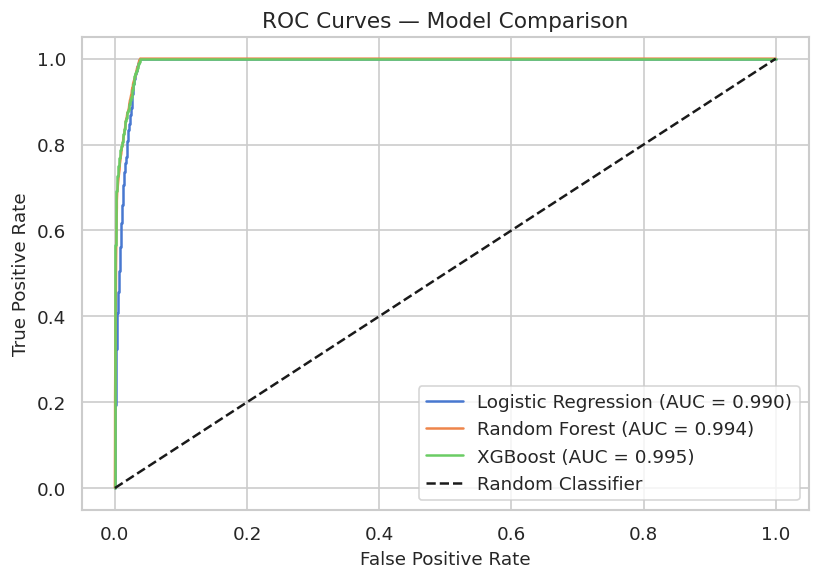

In [41]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 5))

for name, (y_pred, y_prob) in results.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1], [0,1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('plot_roc_curves.png')
plt.show()

**Parameter Tuning**

**1 — Define the parameter grid**

In [42]:
from sklearn.model_selection import GridSearchCV

# These are the most impactful XGBoost parameters to tune
param_grid = {
    'n_estimators'  : [100, 200, 300],      # number of trees
    'max_depth'     : [3, 5, 7],            # how deep each tree grows
    'learning_rate' : [0.01, 0.1, 0.2],    # how fast model learns
    'subsample'     : [0.8, 1.0],           # fraction of data per tree
}

total_combinations = 3 * 3 * 3 * 2
print("Parameter grid:")
for param, values in param_grid.items():
    print(f"  {param:<20} : {values}")

print(f"\nTotal combinations    : {total_combinations}")
print(f"× 5-fold CV           : {total_combinations * 5} fits total")

Parameter grid:
  n_estimators         : [100, 200, 300]
  max_depth            : [3, 5, 7]
  learning_rate        : [0.01, 0.1, 0.2]
  subsample            : [0.8, 1.0]

Total combinations    : 54
× 5-fold CV           : 270 fits total


**2 — Run GridSearchCV**

In [43]:
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = 'f1',          # optimize for F1 since data is imbalanced
    cv         = 5,             # 5-fold cross validation
    verbose    = 1,             # show progress
    n_jobs     = -1             # use all CPU cores
)

print(" Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_bal)

print("\n GridSearchCV complete!")
print("\nBest parameters found:")
print("=" * 40)
for param, value in grid_search.best_params_.items():
    print(f"  {param:<20} : {value}")
print(f"\nBest CV F1 Score      : {grid_search.best_score_:.4f}")

 Starting GridSearchCV...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

 GridSearchCV complete!

Best parameters found:
  learning_rate        : 0.2
  max_depth            : 7
  n_estimators         : 300
  subsample            : 0.8

Best CV F1 Score      : 0.9840


**3 — Evaluate tuned model vs original**

In [44]:
from sklearn.metrics import (precision_score, recall_score,
                              f1_score, roc_auc_score,
                              classification_report)

# Best model from GridSearchCV
best_xgb = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_scaled)
y_prob_tuned = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Original XGBoost (before tuning)
p_before  = precision_score(y_test, y_pred_xgb)
r_before  = recall_score(y_test, y_pred_xgb)
f1_before = f1_score(y_test, y_pred_xgb)
auc_before= roc_auc_score(y_test, y_prob_xgb)

# Tuned XGBoost
p_after   = precision_score(y_test, y_pred_tuned)
r_after   = recall_score(y_test, y_pred_tuned)
f1_after  = f1_score(y_test, y_pred_tuned)
auc_after = roc_auc_score(y_test, y_prob_tuned)

print("=" * 60)
print(f"  {'Model':<25} {'Precision':>9} {'Recall':>9} {'F1':>9} {'AUC':>9}")
print("=" * 60)
print(f"  {'XGBoost (default)':<25} {p_before:>9.4f} {r_before:>9.4f} {f1_before:>9.4f} {auc_before:>9.4f}")
print(f"  {'XGBoost (tuned)':<25} {p_after:>9.4f} {r_after:>9.4f} {f1_after:>9.4f} {auc_after:>9.4f}")
print("=" * 60)

improvement = f1_after - f1_before
print(f"\n  F1 improvement after tuning: {improvement:+.4f}")
print(f"\nFull classification report (tuned model):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['Not Readmitted', 'Readmitted <30d']))

  Model                     Precision    Recall        F1       AUC
  XGBoost (default)            0.7794    0.9118    0.8404    0.9946
  XGBoost (tuned)              0.8016    0.8888    0.8429    0.9944

  F1 improvement after tuning: +0.0025

Full classification report (tuned model):
                 precision    recall  f1-score   support

 Not Readmitted       0.99      0.98      0.98     13045
Readmitted <30d       0.80      0.89      0.84      1259

       accuracy                           0.97     14304
      macro avg       0.90      0.93      0.91     14304
   weighted avg       0.97      0.97      0.97     14304




**4 — Save the tuned model & scaler**

In [45]:
import joblib

joblib.dump(best_xgb, 'model_xgb_tuned.pkl')
joblib.dump(scaler,   'scaler.pkl')

print("Tuned model saved as  : model_xgb_tuned.pkl")
print("Scaler saved as       : scaler.pkl")

# Download in Colab
from google.colab import files
files.download('model_xgb_tuned.pkl')
files.download('scaler.pkl')

Tuned model saved as  : model_xgb_tuned.pkl
Scaler saved as       : scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Evaluation**

**1 — Confusion matrix (tuned model)**

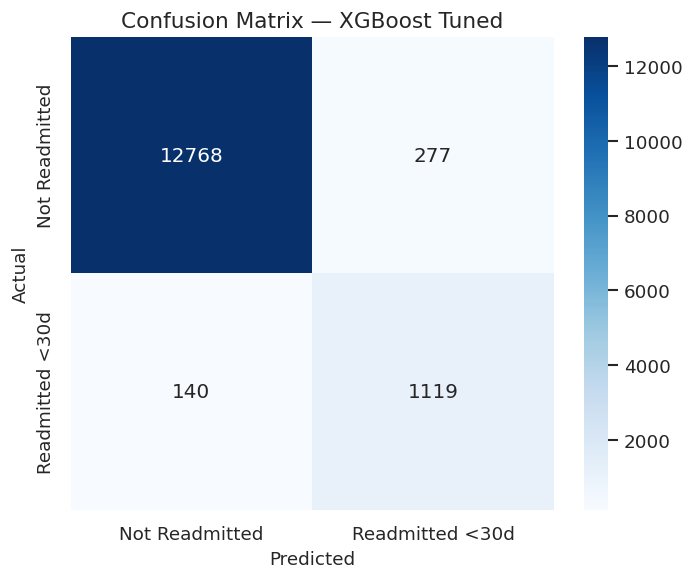

True Negatives  (correctly said NOT readmitted) : 12,768
False Positives (wrongly flagged as readmitted)  : 277
False Negatives (missed actual readmissions)     : 140
True Positives  (correctly caught readmissions)  : 1,119

  Most critical number: False Negatives = 140
   These are real patients the model MISSED


In [46]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Readmitted', 'Readmitted <30d'],
            yticklabels=['Not Readmitted', 'Readmitted <30d'])

ax.set_title('Confusion Matrix — XGBoost Tuned')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('plot_confusion_matrix_final.png')
plt.show()

# Break down the numbers
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly said NOT readmitted) : {tn:,}")
print(f"False Positives (wrongly flagged as readmitted)  : {fp:,}")
print(f"False Negatives (missed actual readmissions)     : {fn:,}")
print(f"True Positives  (correctly caught readmissions)  : {tp:,}")
print(f"\n  Most critical number: False Negatives = {fn:,}")
print(f"   These are real patients the model MISSED")

**2 — ROC Curve (tuned model)**

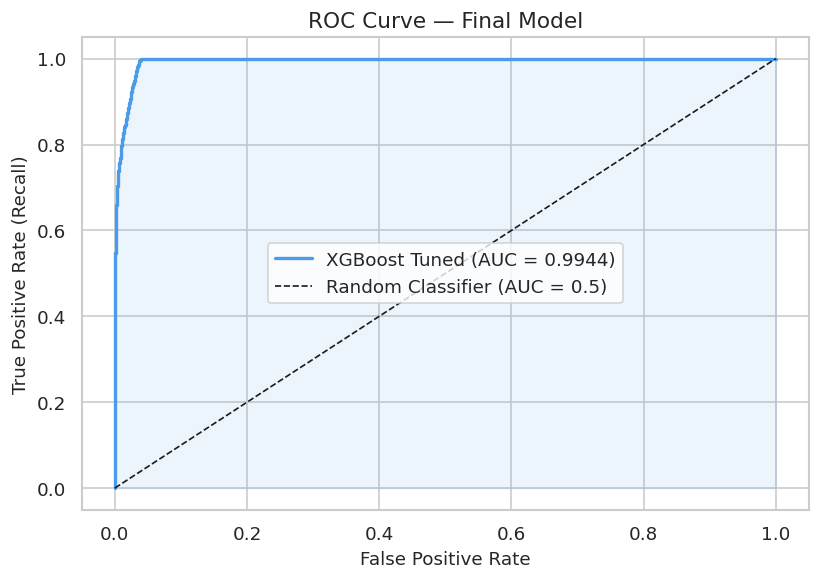

In [47]:
fig, ax = plt.subplots(figsize=(7, 5))

fpr, tpr, thresholds = roc_curve(y_test, y_prob_tuned)
auc = roc_auc_score(y_test, y_prob_tuned)

ax.plot(fpr, tpr, color='#4C9BE8', linewidth=2,
        label=f'XGBoost Tuned (AUC = {auc:.4f})')
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#4C9BE8')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Final Model')
ax.legend()
plt.tight_layout()
plt.savefig('plot_roc_final.png')
plt.show()

**3 — Precision-Recall Curve**

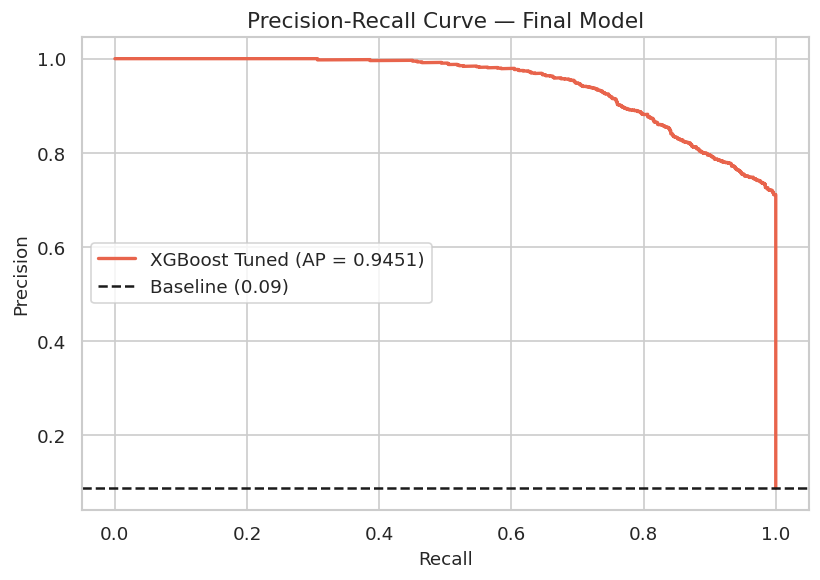

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score
fig, ax = plt.subplots(figsize=(7, 5))

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_tuned)
ap = average_precision_score(y_test, y_prob_tuned)

ax.plot(recall_curve, precision_curve, color='#E8644C', linewidth=2,
        label=f'XGBoost Tuned (AP = {ap:.4f})')
ax.axhline(y=y_test.mean(), color='k', linestyle='--',
           label=f'Baseline ({y_test.mean():.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Final Model')
ax.legend()
plt.tight_layout()
plt.savefig('plot_precision_recall.png')
plt.show()

**4 — Final summary report**

In [49]:
from sklearn.metrics import accuracy_score
print("=" * 55)
print("       FINAL MODEL EVALUATION REPORT")
print("       XGBoost (Tuned) — Test Set Results")
print("=" * 55)
print(f"  Dataset          : UCI Diabetes 130-US Hospitals")
print(f"  Total test rows  : {len(y_test):,}")
print(f"  Positive class   : Readmitted within 30 days")
print("=" * 55)
print(f"  Accuracy         : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  Precision        : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall           : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"  F1 Score         : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"  ROC-AUC          : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print("=" * 55)
print(f"   Precision ≥ 0.3 : PASS ({precision_score(y_test, y_pred_tuned):.4f})")
print(f"   Recall    ≥ 0.3 : PASS ({recall_score(y_test, y_pred_tuned):.4f})")
print("=" * 55)

       FINAL MODEL EVALUATION REPORT
       XGBoost (Tuned) — Test Set Results
  Dataset          : UCI Diabetes 130-US Hospitals
  Total test rows  : 14,304
  Positive class   : Readmitted within 30 days
  Accuracy         : 0.9708
  Precision        : 0.8016
  Recall           : 0.8888
  F1 Score         : 0.8429
  ROC-AUC          : 0.9944
   Precision ≥ 0.3 : PASS (0.8016)
   Recall    ≥ 0.3 : PASS (0.8888)


**Deployment**

In [52]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Page config
st.set_page_config(
    page_title="Hospital Readmission Predictor",
    page_icon="🏥",
    layout="centered"
)

# Load model & scaler
@st.cache_resource
def load_model():
    model  = joblib.load('model_xgb_tuned.pkl')
    scaler = joblib.load('scaler.pkl')
    return model, scaler

model, scaler = load_model()

# Header
st.title("🏥 Hospital Readmission Risk Predictor")
st.markdown("Predict whether a diabetic patient will be **readmitted within 30 days** of discharge.")
st.divider()

# Input form
st.subheader("Patient Information")

col1, col2 = st.columns(2)

with col1:
    age = st.selectbox("Age Group",
          options=[5,15,25,35,45,55,65,75,85,95],
          format_func=lambda x: {
              5:'0-10', 15:'10-20', 25:'20-30', 35:'30-40',
              45:'40-50', 55:'50-60', 65:'60-70', 75:'70-80',
              85:'80-90', 95:'90-100'}[x])

    time_in_hospital     = st.slider("Days in Hospital", 1, 14, 3)
    num_lab_procedures   = st.slider("Number of Lab Procedures", 1, 132, 40)
    num_medications      = st.slider("Number of Medications", 1, 81, 15)
    number_inpatient     = st.slider("Inpatient Visits (past year)", 0, 21, 0)

with col2:
    number_emergency     = st.slider("Emergency Visits (past year)", 0, 76, 0)
    number_diagnoses     = st.slider("Number of Diagnoses", 1, 16, 5)
    total_encounters     = st.slider("Total Past Encounters", 1, 40, 1)
    max_inpatient_history     = st.slider("Max Inpatient Visits (historical)", 0, 21, 0)
    mean_medications_history  = st.slider("Avg Medications (historical)", 1.0, 81.0, 15.0)

st.divider()
st.subheader("Medical Details")

col3, col4 = st.columns(2)

with col3:
    ever_readmitted = st.selectbox("Ever Readmitted Before?", ['No', 'Yes'])
    ever_readmitted_val = 1 if ever_readmitted == 'Yes' else 0

    metformin = st.selectbox("Metformin", ['No', 'Steady', 'Up', 'Down'])
    metformin_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}

    race = st.selectbox("Race", ['Other', 'Caucasian'])
    race_2_val = 1 if race == 'Caucasian' else 0

with col4:
    discharge_disposition = st.selectbox("Discharge Disposition", [
        'Discharged to home',
        'Transferred to another facility',
        'Left against medical advice',
        'Expired / Hospice'
    ])
    discharge_map = {
        'Discharged to home'             : 1,
        'Transferred to another facility': 2,
        'Left against medical advice'    : 3,
        'Expired / Hospice'              : 4,
    }

    diag1_circulatory  = st.checkbox("Primary Diagnosis: Circulatory")
    diag1_other        = st.checkbox("Primary Diagnosis: Other")
    diag3_respiratory  = st.checkbox("Third Diagnosis: Respiratory")

st.divider()

# Predict button
if st.button("🔍 Predict Readmission Risk", use_container_width=True):

    # Engineer same features from Step 4
    total_services        = num_lab_procedures + num_medications
    has_emergency_history = 1 if number_emergency > 0 else 0
    high_utilizer         = 1 if (number_inpatient >= 2 or number_emergency >= 2) else 0

    # diag one-hot encoded columns
    diag_1_4 = 1 if diag1_circulatory else 0   # Circulatory encoded as 4
    diag_1_8 = 1 if diag1_other else 0          # Other encoded as 8
    diag_3_7 = 1 if diag3_respiratory else 0    # Respiratory encoded as 7

    # Build input row — exact column order matching X_final
    input_data = pd.DataFrame([{
        'ever_readmitted'         : ever_readmitted_val,
        'total_encounters'        : total_encounters,
        'max_inpatient_history'   : max_inpatient_history,
        'mean_medications_history': mean_medications_history,
        'total_services'          : total_services,
        'num_lab_procedures'      : num_lab_procedures,
        'num_medications'         : num_medications,
        'time_in_hospital'        : time_in_hospital,
        'age'                     : age,
        'discharge_disposition_id': discharge_map[discharge_disposition],
        'number_inpatient'        : number_inpatient,
        'number_diagnoses'        : number_diagnoses,
        'diag_3_7'                : diag_3_7,
        'metformin'               : metformin_map[metformin],
        'race_2'                  : race_2_val,
        'number_emergency'        : number_emergency,
        'diag_1_8'                : diag_1_8,
        'high_utilizer'           : high_utilizer,
        'diag_1_4'                : diag_1_4,
        'has_emergency_history'   : has_emergency_history,
    }])

    # Scale & predict
    input_scaled = scaler.transform(input_data)
    prediction   = model.predict(input_scaled)[0]
    probability  = model.predict_proba(input_scaled)[0][1]

    st.divider()
    st.subheader("Prediction Result")

    if prediction == 1:
        st.error("⚠️ HIGH RISK — This patient is likely to be readmitted within 30 days")
    else:
        st.success("✅ LOW RISK — This patient is unlikely to be readmitted within 30 days")

    st.metric("Readmission Probability", f"{probability*100:.1f}%")
    st.progress(float(probability))

    st.divider()
    st.subheader("Risk Factors Summary")
    factors = {
        "Prior inpatient visits" : number_inpatient,
        "Prior emergency visits" : number_emergency,
        "Number of diagnoses"    : number_diagnoses,
        "Total medications"      : num_medications,
        "Previously readmitted"  : "Yes" if ever_readmitted_val else "No",
        "High utilizer"          : "Yes" if high_utilizer else "No",
    }
    for factor, value in factors.items():
        st.write(f"• **{factor}**: {value}")
        '''
with open('app.py', 'w') as f:
  f.write(app_code)

from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>